<a href="https://colab.research.google.com/github/nicolasspaniol/deep-learning-pa1/blob/main/notebooks/part0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# **Parte 0 - Teste Unitário Sintético**

In [55]:
class SyntheticEllipseDataset(Dataset):
    def __init__(self, num_samples=500, img_size=128):
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def _generate_sample(self):
        size = self.img_size
        img = np.ones((size, size, 3), dtype=np.uint8) * 255
        mask = np.zeros((size, size), dtype=np.uint8)

        num_ellipses = random.randint(5, 20)
        for i in range(num_ellipses):
            center = (random.randint(10, size-10), random.randint(10, size-10))
            axes = (random.randint(5, 20), random.randint(5, 20))
            angle = random.randint(0, 180)
            gray = random.randint(10, 180)

            cv2.ellipse(img, center, axes, angle, 0, 360, (gray, gray, gray), -1)
            cv2.ellipse(mask, center, axes, angle, 0, 360, 255, -1)

        noise = np.random.normal(0, 30, img.shape)
        img = np.clip(img + noise, 0, 255).astype(np.uint8)

        return img, mask

    def __getitem__(self, idx):
        img, mask = self._generate_sample()

        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask_t = torch.from_numpy(mask).float() / 255.0

        return img_t, mask_t

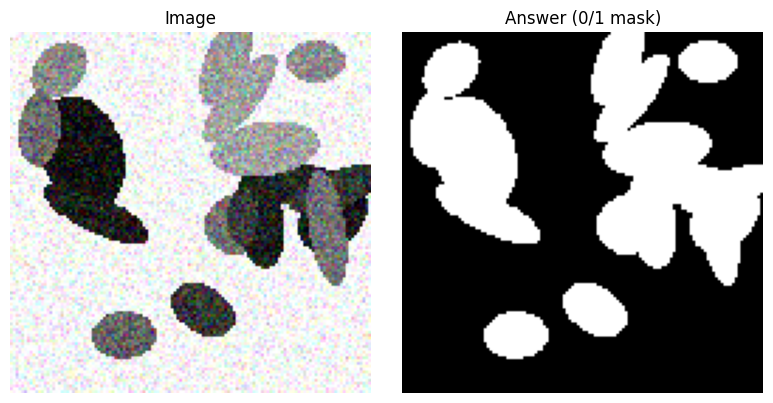

In [56]:
# Exemplo de uso

dataset = SyntheticEllipseDataset(num_samples=1)

# Visualizando uma amostra
img_t, mask_t = dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_t.permute(1, 2, 0).numpy())
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask_t.numpy(), cmap="gray")
axes[1].set_title("Answer (0/1 mask)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# **Parte 1 - Baseline de Segmentação Semântica**

In [17]:
# Treinem uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportem IoU e Dice .
# 2. Extraiam instâncias pelo método ingênuo: limiar + componentes conexos.

class ResUNetEncoderBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int=2):
        super().__init__()

        self.seq = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        )

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)

    def forward(self, x):
        return self.seq(x) + self.shortcut(x)


class ResUNetDecoderBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, skip_channels: int):
        super().__init__()

        self.seq = nn.Sequential(
            nn.BatchNorm2d(in_channels + skip_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        )

        # up sampling
        self.ups = nn.Sequential(
            nn.UpsamplingBilinear2d(scale_factor=2),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        )

        self.shortcut = nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=1)

    # 'skip' aqui é o tensor de skip connection vindo
    # das saídas intermediárias do encoder
    def forward(self, x, skip):
        x = self.ups(x)
        x = torch.cat([x, skip], dim=1) # concat na dimensão 'C'
        return self.seq(x) + self.shortcut(x)


class ResUNet(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.enc0 = ResUNetEncoderBlock(in_channels, 64, stride=1)
        self.enc1 = ResUNetEncoderBlock(64, 128)
        self.enc2 = ResUNetEncoderBlock(128, 256)

        self.bridge = ResUNetEncoderBlock(256, 512)

        self.dec0 = ResUNetDecoderBlock(512, 256, 256)
        self.dec1 = ResUNetDecoderBlock(256, 128, 128)
        self.dec2 = ResUNetDecoderBlock(128, 64, 64)

        self.ending = nn.Sequential(
            nn.LazyConv2d(out_channels, kernel_size=1),
            # nn.Sigmoid() -- vamos usar a saída em logits
        )

    def forward(self, x):
        # encoder
        out0 = self.enc0(x)
        out1 = self.enc1(out0)
        out2 = self.enc2(out1)
        # ponte
        y = self.bridge(out2)
        # decoder
        y = self.dec0(y, out2)
        y = self.dec1(y, out1)
        y = self.dec2(y, out0)

        return self.ending(y)

In [61]:
# Instanciando o modelo
model = ResUNet(3, 1).to(device)

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [59]:
# Teste

model.eval()

dataset = SyntheticEllipseDataset(num_samples=1)
for img, mask in DataLoader(dataset):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))

    # mesmo número de datapoints
    assert y.shape[0] == img.shape[0]
    # shape[1] é o número de canais, que pode variar
    # mesma resolução
    assert y.shape[2] == img.shape[2]
    assert y.shape[3] == img.shape[3]

    fig, ax = plt.subplots()
    ax.imshow(y[0,0].detach().cpu().numpy(), cmap="gray")
    ax.set_title("Saída do modelo")
    ax.axis("off")
    plt.show()

    break

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [60]:
# Treinando o modelo no dataset sintético (teste unitário)

dataset = SyntheticEllipseDataset(num_samples=512)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

model.train()
for batch, (X, y) in enumerate(loader):
    X, y = X.to(device), y.to(device)

    print(y.dtype, y_hat.dtype)
    print(y.min(), y.max())
    print(y_hat.min(), y_hat.max())

    y_hat = model(X)
    loss = loss_fn(y_hat, y.long().squeeze(1))

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    print(f'{batch} - loss={loss}')

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
